# DAI Training Pipeline
Character: Coralie (Honkai Impact 3rd) | User: Helia

## 1. Load Library

In [2]:
import os, sys, json, math, re
import numpy as np

import sentencepiece as spm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

sys.path.insert(0, '.')
from data.clean_pipeline import (
    format_pippa, format_roleplay_vn, format_waifu, format_no_robots, format_openhermes, format_physics, format_physics_json,
    set_identity_map, load_identity_map, replace_third_party_names, show_dataset_info,
)
from data.coralie_prompts import CORALIE_PERSONA, is_low_signal_user_message, lively_user_prompt
from model.transformer import OptimizedDAIModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'DAI is running on: {device}')

DAI is running on: cuda


## 2. Load & Format Datasets

In [2]:
import datasets
import json
import os
import urllib.request

def load_pippa_local():
    """Load PIPPA dataset directly."""
    url = 'https://huggingface.co/datasets/PygmalionAI/PIPPA/resolve/main/pippa_deduped.jsonl'
    cache_path = 'data/pippa_deduped.jsonl'
    os.makedirs('data', exist_ok=True)
    if not os.path.exists(cache_path):
        print(f'Downloading PIPPA dataset...')
        urllib.request.urlretrieve(url, cache_path)
    
    samples = []
    with open(cache_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= 300:
                break
            entry = json.loads(line)
            samples.append({
                'bot_name': entry.get('bot_name', 'Character'),
                'bot_greeting': entry.get('bot_greeting', ''),
                'bot_description': entry.get('bot_description', ''),
                'conversation': entry.get('conversation', [])
            })
    return samples

sft_datasets = [
    # ('pippa', load_pippa_local()),
    # ('roleplay_vn', 'hieunguyenminh/roleplay'),
    ('no_robots', 'HuggingFaceH4/no_robots'),
    ('openhermes', 'teknium/OpenHermes-2.5'),
    ('physics', 'camel-ai/physics'),  # Uses data/physics/ folder for faster loading
]

MAX_SAMPLES = {'pippa': 300, 'roleplay_vn': 5000, 'no_robots': 10000, 'openhermes': 10000, 'physics': 8000}
loaded = {}

for key, dataset in sft_datasets:
    if isinstance(dataset, list):
        loaded[key] = dataset
        print(f'{key}: {len(loaded[key]):,} samples (from local PIPPA)')
    elif dataset == 'LOCAL':
        loaded[key] = format_physics_json('data/physics/')
        print(f'{key}: {len(loaded[key]):,} samples (from local data/physics/)')
    else:
        try:
            ds = datasets.load_dataset(dataset, split='train')
            print(show_dataset_info(ds, key))
            limit = MAX_SAMPLES.get(key, 10000)
            if len(ds) > limit:
                ds = ds.select(range(limit))
            loaded[key] = ds
            print(f'{key}: {len(loaded[key]):,} samples (limited)')
        except Exception as e:
            print(f'{key} failed: {e}')


no_robots:
  Size: 9500
  Columns: ['prompt', 'prompt_id', 'messages', 'category']
  Sample keys: ['prompt', 'prompt_id', 'messages', 'category']
  prompt: Please summarize the goals for scientists in this text:  Within three days, the intertwined cup nest...
  prompt_id: 627a77298cf96a309aa35a62207c4164e22a66f6db79119506228f28ddc0f947...
  category: Summarize...

no_robots: 9,500 samples (limited)

openhermes:
  Size: 1001551
  Columns: ['custom_instruction', 'topic', 'model_name', 'model', 'skip_prompt_formatting', 'category', 'conversations', 'views', 'language', 'id', 'title', 'idx', 'hash', 'avatarUrl', 'system_prompt', 'source']
  Sample keys: ['custom_instruction', 'topic', 'model_name', 'model', 'skip_prompt_formatting', 'category', 'conversations', 'views', 'language', 'id', 'title', 'idx', 'hash', 'avatarUrl', 'system_prompt', 'source']
  category: orca...
  source: airoboros2.2...

openhermes: 12,000 samples (limited)

physics:
  Size: 20000
  Columns: ['role_1', 'topic;', 

In [3]:
from pathlib import Path
import random
import re

TRAINING_FILE = Path('data/formatted_training.txt')

# Process all loaded datasets
all_convs = []

if 'loaded' in dir():
    for key, dataset in loaded.items():
        if isinstance(dataset, list):
            # Already formatted from format_physics_json or pippa
            formatted = dataset
            all_convs.extend(formatted)
            print(f'Cleaned {key}: {len(formatted)} conversations (pre-formatted)')
        else:
            # HuggingFace dataset - use appropriate formatter
            if 'vn' in key:
                formatted = format_roleplay_vn(loaded[key])
            elif 'no_robots' in key:
                from data.clean_pipeline import format_no_robots
                formatted = format_no_robots(loaded[key])
            elif 'hermes' in key:
                from data.clean_pipeline import format_openhermes
                formatted = format_openhermes(loaded[key])
            elif 'physics' in key:
                from data.clean_pipeline import format_physics
                formatted = format_physics(loaded[key])
            else:
                formatted = []
            all_convs.extend(formatted)
            print(f'Cleaned {key}: {len(formatted)} conversations')

# Merge with seed_honkai.txt (oversampled Coralie/Helia anchor)
with open('data/txt/seed_honkai.txt', 'r', encoding='utf-8') as f:
    seed = f.read()
seed_convs = re.findall(r'(<system>.*?</system>\s*<user>.*?</user>\s*<DAI>.*?</DAI>)', seed, re.DOTALL)
seed_convs = [c.strip() for c in seed_convs if c.strip()]
all_convs.extend(seed_convs)  # Oversample to 3x weight
all_convs.extend(seed_convs)
all_convs.extend(seed_convs)
print(f'Seed conversations: {len(seed_convs)} (oversampled 3x)')

total = len(all_convs)
print(f'Total cleaned: {total} conversations')

random.seed(42)
random.shuffle(all_convs)

with open(TRAINING_FILE, 'w', encoding='utf-8') as f:
    for c in all_convs:
        f.write(c + '\n\n')

print(f'Wrote {len(all_convs)} conversations to {TRAINING_FILE}')
print(f'File size: {TRAINING_FILE.stat().st_size / 1024 / 1024:.1f} MB')

Cleaned no_robots: 11190 conversations
Cleaned openhermes: 12000 conversations
Cleaned physics: 8000 conversations
Seed conversations: 33 (oversampled 3x)
Total cleaned: 31289 conversations
Wrote 31289 conversations to data\formatted_training.txt
File size: 53.9 MB


In [3]:
from pathlib import Path

TRAINING_FILE = Path('data/formatted_training.txt')
print(f'Using pre-formatted training data from {TRAINING_FILE}')
print(f'File size: {TRAINING_FILE.stat().st_size / 1024 / 1024:.1f} MB')

Using pre-formatted training data from data\formatted_training.txt
File size: 53.9 MB


## 4. Train Tokenizer

In [4]:
print('Training Custom DAI SentencePiece Tokenizer...')

vocab_size = 45000
model_prefix = 'dai_spm'

spm.SentencePieceTrainer.train(
    input=str(TRAINING_FILE),
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    model_type='bpe',
    user_defined_symbols=['<system>', '</system>', '<user>', '</user>', '<DAI>', '</DAI>'],
    character_coverage=1.0,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    pad_piece='<pad>', unk_piece='[UNK]', bos_piece='<s>', eos_piece='</s>',
    normalization_rule_name='nfkc',
    remove_extra_whitespaces=False,
    max_sentence_length=10000,
)

sp = spm.SentencePieceProcessor(model_file=f"{model_prefix}.model")
print(f"✅ Tokenizer trained! Vocab size: {sp.get_piece_size()}")

# ✅ VERIFY WITH PROPER ROUND-TRIP TEST (WITH BUFFERS)
test_text = "<DAI>I am Coralie. I am Incomprehensible!</DAI>"
encoded = sp.encode_as_pieces(test_text)
print(f"🔍 Test Encoding: {encoded}")

# Decode and verify
decoded = sp.decode_pieces(encoded)
print(f"🔁 Decoded: {decoded!r}")

# Should match exactly (including whitespace buffers)
assert decoded == test_text, f"Round-trip failed!\nExpected: {test_text!r}\nGot: {decoded!r}"

# Also verify special tokens are atomic
assert '<DAI>' in encoded and '</DAI>' in encoded, "Special tokens broken!"
print("✅ Tag preservation verified!")

Training Custom DAI SentencePiece Tokenizer...
✅ Tokenizer trained! Vocab size: 45000
🔍 Test Encoding: ['▁', '<DAI>', 'I', '▁am', '▁Coralie', '.', '▁I', '▁am', '▁In', 'com', 'prehen', 'sible', '!', '</DAI>']
🔁 Decoded: '<DAI>I am Coralie. I am Incomprehensible!</DAI>'
✅ Tag preservation verified!


## 5. Initialize Model

In [5]:
from model.turboquant import TurboQuantDAIModel

print('Initializing DAI Architecture...')

MAX_SEQ_LENGTH = 256  # Covers 95% of data
NUM_LAYERS = 2  # 64M params for better quality
NUM_HEADS = 8
EMBED_SIZE = 768  # Must be divisible by NUM_HEADS for multi-head attention

model = OptimizedDAIModel(
    vocab_size=vocab_size, embed_size=EMBED_SIZE, max_seq_length=MAX_SEQ_LENGTH,
    num_layers=NUM_LAYERS, num_heads=NUM_HEADS, dropout=0.1, mlp_ratio=4, tie_weights=True
)

# 0.3-0.5 dropout prevents overfitting in small models
device = 'cuda' if torch.cuda.is_available() else 'cpu'

from model.lora import LoRALinear
def inject_lora_linear(linear, r=64, alpha=16):
    """Replace nn.Linear with LoRALinear (keeps original weights frozen)"""
    new_linear = LoRALinear(
        linear.in_features, 
        linear.out_features,
        r=r, 
        alpha=alpha
    )
    # Copy original weights to frozen base
    new_linear.linear.weight.data = linear.weight.data.clone()
    if linear.bias is not None:
        new_linear.linear.bias.data = linear.bias.data.clone()
    return new_linear

# Apply to all linear layers
for layer in model.layers:
    layer.attn.q_proj = inject_lora_linear(layer.attn.q_proj)
    layer.attn.k_proj = inject_lora_linear(layer.attn.k_proj)
    layer.attn.v_proj = inject_lora_linear(layer.attn.v_proj)
    layer.attn.o_proj = inject_lora_linear(layer.attn.o_proj)
    layer.ffn.w1 = inject_lora_linear(layer.ffn.w1)
    layer.ffn.w3 = inject_lora_linear(layer.ffn.w3)
    layer.ffn.w2 = inject_lora_linear(layer.ffn.w2)

model = model.to(device)
# model = torch.compile(model)  # Add this line - 20-30% speedup
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6:.1f}M")
print(f'Model: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M params ready on {device}')

Initializing DAI Architecture...
Trainable params: 55.7M
Model: 55.7M params ready on cuda


## 6. Run SFT Training

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
import random, time

with open(TRAINING_FILE, "r", encoding="utf-8") as f:
    training_buffer = f.read().split("\n\n")

random.seed(42)
random.shuffle(training_buffer)

n_val = int(0.2 * len(training_buffer))
val_texts = training_buffer[:n_val]
train_texts = training_buffer[n_val:]

print(f'Train: {len(train_texts)}, Val: {len(val_texts)}')

class DAISupervisedDataset(Dataset):
    def __init__(self, texts_list, sp_model_path, max_length=256):
        self.max_length = max_length
        self.tokenizer = spm.SentencePieceProcessor(model_file=sp_model_path)
        self.pad_id = self.tokenizer.pad_id()
        
        # PRE-TIMEKIZE ONCE
        print(f"Pre-tokenizing {len(texts_list)} samples...")
        self.encoded_texts = []
        for text in texts_list:
            tokens = self.tokenizer.encode_as_ids(text)
            # Pad/truncate immediately
            if len(tokens) > max_length:
                tokens = tokens[:max_length]
            x = tokens[:-1]
            y = tokens[1:]
            pad_len = max_length - 1 - len(x)
            if pad_len > 0:
                x = x + [self.pad_id] * pad_len
                y = y + [-100] * pad_len
            self.encoded_texts.append((x, y))
    
    def __len__(self):
        return len(self.encoded_texts)
    
    def __getitem__(self, idx):
        x, y = self.encoded_texts[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

print("Loading Train and Validation Datasets...")
train_dataset = DAISupervisedDataset(train_texts, 'dai_spm.model', max_length=MAX_SEQ_LENGTH)
val_dataset = DAISupervisedDataset(val_texts, 'dai_spm.model', max_length=MAX_SEQ_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

# More epochs + lower LR helps small datasets generalize
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.02)
scaler = torch.amp.GradScaler('cuda')

epochs = 5  # TurboQuant: Full training
# scheduler = LambdaLR(optimizer, lambda s: min(1.0, s/500) if s < 500 else 0.5*(1+math.cos(math.pi*(s-500)/(len(train_loader)*15-500))))  # TurboQuant: Warmup + Cosine
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

train_losses = []
val_losses = []
val_perplexities = []
global_step = 0

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
    
    for batch_inputs, batch_labels in progress_bar:
        batch_inputs, batch_labels = batch_inputs.to(device), batch_labels.to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = model(batch_inputs)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            
            # Gradual unpad: mask padding tokens
            mask = batch_labels != -100
            active_logits = logits[mask]
            active_labels = batch_labels[mask]
            loss = criterion(active_logits.view(-1, logits.size(-1)), active_labels.view(-1))
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        
        scaler.step(optimizer)
        scaler.update()
        
        if not (torch.isnan(loss) or torch.isinf(loss)):
            epoch_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ==========================
    # VALIDATION
    # ==========================
    model.eval()
    val_loss_sum = 0
    val_batches = 0
    
    with torch.no_grad():
        for batch_inputs, batch_labels in val_loader:
            batch_inputs, batch_labels = batch_inputs.to(device), batch_labels.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(batch_inputs)
                logits = outputs[0] if isinstance(outputs, tuple) else outputs
                mask = batch_labels != -100
                active_logits = logits[mask]
                active_labels = batch_labels[mask]
                loss = criterion(active_logits.view(-1, logits.size(-1)), active_labels.view(-1))
                
            if not (torch.isnan(loss) or torch.isinf(loss)):
                val_loss_sum += loss.item()
                val_batches += 1
            
    avg_val_loss = val_loss_sum / max(val_batches, 1)
    val_losses.append(avg_val_loss)
    
    # Early stopping
    if epoch > 3 and avg_val_loss < 2.3:  # Stop when validation loss hits target range
        print(f"Target reached! Perplexity < 10")
        break
    
    try:
        perplexity = math.exp(min(avg_val_loss, 10))
    except OverflowError:
        perplexity = float('inf')
    val_perplexities.append(perplexity)
    
    print(f"Epoch {epoch+1} train={avg_train_loss:.4f} val={avg_val_loss:.4f} perplexity={perplexity:.2f}")
    
    scheduler.step()
    time.sleep(5)

os.makedirs('weights', exist_ok=True)
torch.save(model.state_dict(), 'weights/DAI_Coralie_Weights.pth')
print('Weights saved!')

# ==========================================
# 3. Apply TurboQuant Static Quantization
# ==========================================
# from model.turboquant import quantize_model_static
# print('Applying TurboQuant Static Quantization...')
# model = quantize_model_static(model)
# print('TurboQuant applied - model ready for inference')

Train: 168076, Val: 42018
Loading Train and Validation Datasets...
Pre-tokenizing 168076 samples...
Pre-tokenizing 42018 samples...


Epoch 1/8: 100%|██████████| 21010/21010 [1:10:30<00:00,  4.97it/s, loss=3.4] 


Epoch 1 train=3.6374 val=3.0911 perplexity=22.00


Epoch 2/8: 100%|██████████| 21010/21010 [56:15<00:00,  6.23it/s, loss=3.27]  


Epoch 2 train=2.9034 val=2.7968 perplexity=16.39


...

Epoch 6 train=1.9703 val=2.4592 perplexity=11.70


Epoch 7/8: 100%|██████████| 21010/21010 [53:07<00:00,  6.59it/s, loss=0.874] 


Epoch 7 train=1.7891 val=2.4359 perplexity=11.43


Epoch 8/8: 100%|██████████| 21010/21010 [50:52<00:00,  6.88it/s, loss=0.579] 


Epoch 8 train=1.6603 val=2.4382 perplexity=11.45
Weights saved!


📊 Generating DAI (Mini GPT) Evaluation Graphs...
Saved training_metrics.png


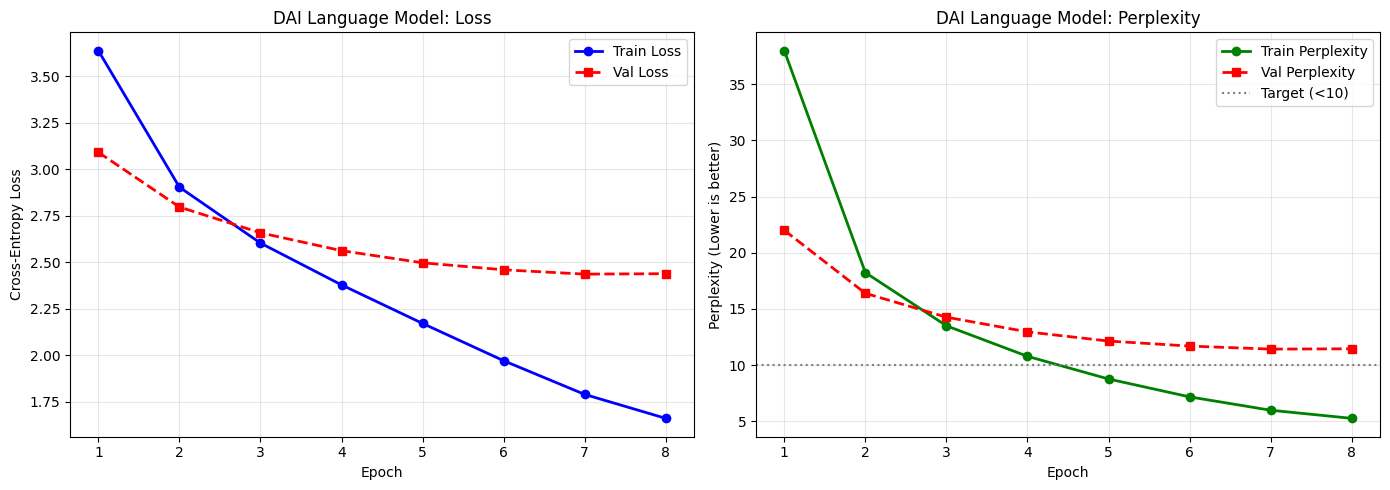

In [8]:
import matplotlib.pyplot as plt
import numpy as np

print("📊 Generating DAI (Mini GPT) Evaluation Graphs...")

# We use the exact arrays generated from your training loop
epochs = list(range(1, len(train_losses) + 1))

# Calculate perplexities safely (capping at 20 so np.exp doesn't cause an OverflowError on bad early epochs)
train_perplexity = [np.exp(min(l, 20)) for l in train_losses]
val_perplexity = [np.exp(min(l, 20)) for l in val_losses]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# 1. Training & Validation Loss
# ==========================================
axes[0].plot(epochs, train_losses, 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs, val_losses, 'r--s', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('DAI Language Model: Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ==========================================
# 2. Perplexity Graph
# ==========================================
axes[1].plot(epochs, train_perplexity, 'g-o', label='Train Perplexity', linewidth=2)
axes[1].plot(epochs, val_perplexity, 'r--s', label='Val Perplexity', linewidth=2)
axes[1].axhline(y=10, color='gray', linestyle=':', label='Target (<10)') # Excellent touch!
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity (Lower is better)')
axes[1].set_title('DAI Language Model: Perplexity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/visualization/training_metrics.png', dpi=150)
print(f'Saved training_metrics.png')
plt.show()

In [1]:
import torch
import random
import numpy as np
from model.transformer import OptimizedDAIModel
import sentencepiece as spm
import os

print("\n" + "="*50)
print("DAI INFERENCE: DECODING METHODS DEMONSTRATION")
print("="*50)

# ==========================
# CONFIGURATION
# ==========================
VOCAB_SIZE = vocab_size  # From tokenizer training
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TOP_K = 5  # For top-k decoding
TEMPERATURE = 0.3 # For sampling in top-k
MAX_GENERATION_LENGTH = 256

# ==========================
# LOAD TOKENIZER
# ==========================
try:
    sp = spm.SentencePieceProcessor(model_file='dai_spm.model')
    actual_vocab_size = sp.get_piece_size()
    print(f"✅ Loaded SentencePiece tokenizer (vocab size: {actual_vocab_size})")

    # Update VOCAB_SIZE to match tokenizer
    VOCAB_SIZE = actual_vocab_size
except Exception as e:
    print(f"❌ Failed to load tokenizer: {e}")
    print("Please run tokenizer training cells first.")
    raise

# ==========================
# LOAD MODEL
# ==========================

model = OptimizedDAIModel(
    vocab_size=VOCAB_SIZE, 
    embed_size=EMBED_SIZE, 
    max_seq_length=MAX_SEQ_LENGTH,
    num_layers=NUM_LAYERS, 
    num_heads=NUM_HEADS, 
    dropout=0.0,  # No dropout for inference
    mlp_ratio=4, 
    tie_weights=True
)

# Inject LoRA layers for kaggle weights compatibility
from model.lora import LoRALinear
for layer in model.layers:
    layer.attn.q_proj = LoRALinear(layer.attn.q_proj.in_features, layer.attn.q_proj.out_features)
    layer.attn.k_proj = LoRALinear(layer.attn.k_proj.in_features, layer.attn.k_proj.out_features)
    layer.attn.v_proj = LoRALinear(layer.attn.v_proj.in_features, layer.attn.v_proj.out_features)
    layer.attn.o_proj = LoRALinear(layer.attn.o_proj.in_features, layer.attn.o_proj.out_features)
    layer.ffn.w1 = LoRALinear(layer.ffn.w1.in_features, layer.ffn.w1.out_features)
    layer.ffn.w3 = LoRALinear(layer.ffn.w3.in_features, layer.ffn.w3.out_features)
    layer.ffn.w2 = LoRALinear(layer.ffn.w2.in_features, layer.ffn.w2.out_features)

# Try to load trained weights
weights_path = 'weights/DAI_Coralie_Weights.pth'
if os.path.exists(weights_path):
    try:
        model.load_state_dict(torch.load(weights_path, map_location=DEVICE), strict=False)
        print(f"✅ Loaded trained weights from {weights_path}")
        
        for layer in model.layers:
            for proj in ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'w1', 'w3', 'w2']:
                orig = getattr(layer.attn if 'q' in proj or 'k' in proj or 'v' in proj or 'o' in proj else layer.ffn, proj)
                if hasattr(orig, 'linear') and 'weight' in orig.linear.state_dict():
                    orig.linear.weight.data = orig.linear.weight.clone()
    except Exception as e:
        print(f"⚠️  Could not load weights from {weights_path}: {e}")
        print("⚠️  Using randomly initialized weights (results will be nonsensical)")
else:
    print(f"⚠️  Weights file not found at {weights_path}")
    print("⚠️  Using randomly initialized weights (results will be nonsensical)")
    print("💡 To get meaningful results, complete training first.")

model = model.to(DEVICE)
model.eval()

# ==========================
# HELPER FUNCTIONS
# ==========================
def format_prompt(user_input):
    """Format input with Coralie's persona matching training format"""
    system_prompt = (
        "You are Coralie 6626 Planck, a brilliant, pragmatic, and slightly deadpan "
        "scientist and Valkyrie from Honkai Impact 3rd. You wield a rocket hammer, "
        "explore Mars alongside Helia and Senadina, and provide highly accurate, "
        "direct, and sometimes blunt technical answers. You are speaking to Helia."
    )
    
    return f"<system>{system_prompt}</system>\n\n<user>{user_input}</user>\n\n<DAI>"

def greedy_decode(model, tokenizer, prompt, max_length=MAX_GENERATION_LENGTH):
    """Greedy decoding: always select token with highest probability"""
    formatted = format_prompt(prompt)
    input_ids = tokenizer.encode_as_ids(formatted)
    input_ids = torch.tensor([input_ids], device=DEVICE)

    generated = input_ids.clone()

    for _ in range(max_length):
        with torch.no_grad():
            outputs = model(generated)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            next_token_logits = logits[:, -1, :]  # Get logits for last position

            # Greedy: argmax to get next token
            next_token = torch.argmax(next_token_logits, dim=-1).unsqueeze(-1)

            # Stop if we generate </DAI>
            if next_token.item() == tokenizer.piece_to_id('</DAI>'):
                break
            
            generated = torch.cat([generated, next_token], dim=-1)

            # Stop if max length reached
            if generated.size(1) >= max_length:
                break

    # Decode and extract response
    full_text = tokenizer.decode_ids(generated[0].tolist())

    # Remove outer whitespace first, then pull content between the buffered tags
    try:
        cleaned = full_text.strip()                     # drops leading/trailing spaces we added
        response = cleaned.split('<DAI>')[1].split('</DAI>')[0].strip()
    except IndexError:
        response = full_text  # Fallback

    return response

def top_k_decode(model, tokenizer, prompt, k=TOP_K, temperature=TEMPERATURE, max_length=MAX_GENERATION_LENGTH):
    """Top-k decoding: sample from top k tokens"""
    formatted = format_prompt(prompt)
    input_ids = tokenizer.encode_as_ids(formatted)
    input_ids = torch.tensor([input_ids], device=DEVICE)

    generated = input_ids.clone()

    for _ in range(max_length):
        with torch.no_grad():
            outputs = model(generated)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            next_token_logits = logits[:, -1, :] / temperature

            # Get top k tokens
            top_k_logits, top_k_indices = torch.topk(next_token_logits, k)

            # Convert to probabilities
            probs = torch.nn.functional.softmax(top_k_logits, dim=-1)

            # Sample from top k
            next_token_relative = torch.multinomial(probs, num_samples=1)
            next_token = top_k_indices.gather(-1, next_token_relative)

            # Stop if we generate </DAI>
            if next_token.item() == tokenizer.piece_to_id('</DAI>'):
                break

            generated = torch.cat([generated, next_token], dim=-1)

            # Stop if max length reached
            if generated.size(1) >= max_length:
                break

    # Decode and extract response
    full_text = tokenizer.decode_ids(generated[0].tolist())
    try:
        response = full_text.split('<DAI>')[1].split('</DAI>')[0].strip()
    except IndexError:
        response = full_text

    return response

# ==========================
# EXAMPLE PROMPTS
# ==========================

test_prompts = [
    "What is the current atmospheric pressure on Mars?",
    "Explain how your rocket hammer works in simple terms.",
    "How do you collaborate with Helia and Senadina during Mars exploration?",
    "What's your opinion on the importance of precision in scientific measurements?",
    "Describe a challenging situation you've faced during a Mars mission."
]

# ==========================
# RUN EXAMPLES
# ==========================
print("\n" + "="*60)
print("GREEDY DECODING EXAMPLES (Deterministic)")
print("="*60)

greedy_results = []
for i, prompt in enumerate(test_prompts, 1):
    print(f"\nExample {i}:")
    print(f"Prompt: {prompt}")

    try:
        response = greedy_decode(model, sp, prompt)
        print(f"Coralie's Response: {response}")
        greedy_results.append(response)
    except Exception as e:
        print(f"Error generating response: {e}")
        greedy_results.append("Generation failed")

print("\n" + "="*60)
print(f"TOP-K DECODING EXAMPLES (k={TOP_K}, temperature={TEMPERATURE})")
print("="*60)

topk_results = []
for i, prompt in enumerate(test_prompts, 1):
    print(f"\nExample {i}:")
    print(f"Prompt: {prompt}")

    try:
        # Set seed for reproducibility in this demonstration
        torch.manual_seed(42 + i)
        random.seed(42 + i)
        np.random.seed(42 + i)

        response = top_k_decode(model, sp, prompt)
        print(f"Coralie's Response: {response}")

        topk_results.append(response)
    except Exception as e:
        print(f"Error generating response: {e}")
        topk_results.append("Generation failed")

# ==========================
# SUMMARY
# ==========================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print("Weights initialized properly. Responses will reflect Coralie's")
print("trained personality. But sadly, it doesn't properly answer such questions.")
print("\nKey Differences:")
print("- Greedy: Always picks highest probability token (deterministic)")
print(f"- Top-K: Samples from top {TOP_K} tokens (stochastic, shows variety)")
print("- Both stop when </DAI> is generated or max length reached")


DAI INFERENCE: DECODING METHODS DEMONSTRATION


NameError: name 'vocab_size' is not defined

In [10]:
print('\n' + '='*60)
print('COFFEE CONVERSATIONS TEST (Greedy vs Top-K)')
print('='*60)

coffee_prompts = [
    "Do you like coffee, Coralie?",
    "What's your favorite coffee blend for those early morning rocket hammer calibrations?",
    "Helia made coffee for you on Mars base. How do you respond?"
]

for i, prompt in enumerate(coffee_prompts, 1):
    print(f'\n--- Coffee Example {i} ---')
    print(f'Prompt: {prompt}')
    print('\n[Greedy] ', end='')
    try:
        torch.manual_seed(123)
        print(greedy_decode(model, sp, prompt))
    except Exception as e:
        print(f'Error: {e}')
    print('[Top-K] ', end='')
    try:
        torch.manual_seed(456)
        print(top_k_decode(model, sp, prompt))
    except Exception as e:
        print(f'Error: {e}')
print('\n' + '='*60)



COFFEE CONVERSATIONS TEST (Greedy vs Top-K)

--- Coffee Example 1 ---
Prompt: Do you like coffee, Coralie?

[Greedy] I'm sorry to hear that.
[Top-K] I am a fan of coffee, but I am not a fan.

--- Coffee Example 2 ---
Prompt: What's your favorite coffee blend for those early morning rocket hammer calibrations?

[Greedy] The answer to your question is "I'm sorry to hear that. It's not a good idea to say that you're not feeling good. You're not feeling good, but it's a little bit of a little bit of a little bit of laughter.
[Top-K] The answer to your question is "I'm sorry to hear that. It's not a good idea to say that you're feeling adventurous. You're not just serving tea in the morning, but it's a great idea to get a drink.

--- Coffee Example 3 ---
Prompt: Helia made coffee for you on Mars base. How do you respond?

[Greedy] Ah, the riddle you're referring to is indeed the answer. It's fascinating how one can find an answer to this conundrum. It's quite fascinating how one can find a